NAME: Andrew Whitmill
ID: 1001839036

References:
 - Code given in the assignment as a starting point
 - https://www.datacamp.com/tutorial/pytorch-cnn-tutorial
 - https://pub.towardsai.net/cnns-and-transfer-learning-with-pytorch-from-image-features-to-pre-trained-models-e45ba0f21d9d

 - https://www.geeksforgeeks.org/deep-learning/image-classification-using-pytorch-lightning/
 - https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
 - ChatGPT for debugging and report formatting

In [ ]:
!pip install pytorch-lightning torchvision

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [ ]:
IMG_SIZE = 64
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dataset = torchvision.datasets.Imagenette(
    root="./data",
    split="train",
    transform=transform,
    download=True
)

val_dataset = torchvision.datasets.Imagenette(
    root="./data",
    split="val",
    transform=transform,
    download=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

In [ ]:
class BasicCNN(pl.LightningModule):
    def __init__(self, num_classes=10):
        super().__init__()

        self.train_losses = []
        self.val_losses = []
        self.val_accs = []

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        self.train_losses.append(loss.item())
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()

        self.val_losses.append(loss.item())
        self.val_accs.append(acc.item())

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [ ]:
model = BasicCNN()

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    mode="min"
)

trainer = pl.Trainer(
    max_epochs=5,  # keep small for the sanity of my cpu/gpu
    callbacks=[early_stop],
    accelerator="auto"
)

trainer.fit(model, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │ 23.6 K │ train │     0 │
│ 1 │ fc   │ Sequential │  9.6 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


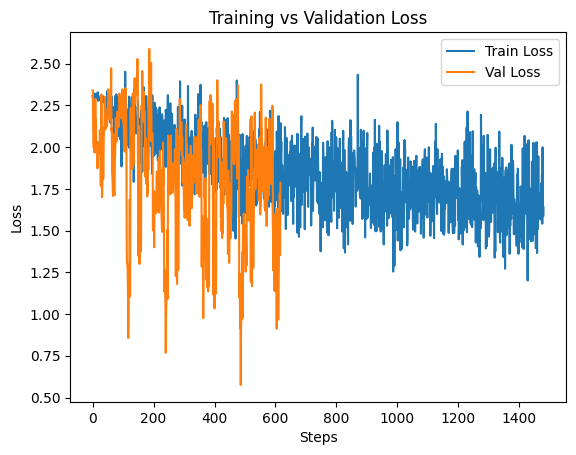

In [ ]:
plt.plot(model.train_losses, label="Train Loss")
plt.plot(model.val_losses, label="Val Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Test Accuracy:", correct / total)

Test Accuracy: 0.4191082802547771


In [ ]:
class AllConvNet(pl.LightningModule):
    def __init__(self, num_classes=10):
        super().__init__()

        self.train_losses = []
        self.val_losses = []
        self.val_accs = []

        self.model = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, num_classes, 1),  # outputs class channels
            nn.AdaptiveAvgPool2d((1, 1))     # global average pooling
        )

    def forward(self, x):
        x = self.model(x)
        return x.view(x.size(0), -1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)

        self.train_losses.append(loss.item())
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)

        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()

        self.val_losses.append(loss.item())
        self.val_accs.append(acc.item())

        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=1e-3)

In [ ]:
model2 = AllConvNet()

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto"
)

trainer.fit(model2, train_loader, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │ 94.5 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 94.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 94.5 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 11                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
correct = 0
total = 0

model2.eval()

with torch.no_grad():
    for x, y in val_loader:
        logits = model2(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("All-Conv Test Accuracy:", correct / total)

All-Conv Test Accuracy: 0.47770700636942676


In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

print("Basic CNN params:", count_params(model))
print("All-Conv params:", count_params(model2))

Basic CNN params: 33194
All-Conv params: 94538


In [ ]:
transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),

    transforms.ToTensor(),
])

In [ ]:
train_dataset_aug = torchvision.datasets.Imagenette(
    root="./data",
    split="train",
    transform=transform_aug,
    download=True
)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

In [ ]:
model_reg = BasicCNN()

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto"
)

trainer.fit(model_reg, train_loader_aug, val_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │ 23.6 K │ train │     0 │
│ 1 │ fc   │ Sequential │  9.6 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
correct = 0
total = 0

model_reg.eval()

with torch.no_grad():
    for x, y in val_loader:
        logits = model_reg(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print("Regularized Model Accuracy:", correct / total)

Regularized Model Accuracy: 0.41885350318471337


In [ ]:
transform_cifar = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_cifar = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    transform=transform_cifar,
    download=True
)

test_cifar = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    transform=transform_cifar,
    download=True
)

train_loader_cifar = DataLoader(train_cifar, batch_size=32, shuffle=True)
test_loader_cifar = DataLoader(test_cifar, batch_size=32)

In [ ]:
model_scratch = BasicCNN()

trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto"
)

trainer.fit(model_scratch, train_loader_cifar, test_loader_cifar)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │ 23.6 K │ train │     0 │
│ 1 │ fc   │ Sequential │  9.6 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 33.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
def evaluate(model, loader):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for x, y in loader:
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

print("Scratch Accuracy:", evaluate(model_scratch, test_loader_cifar))

Scratch Accuracy: 0.5133


In [ ]:
torch.save(model.state_dict(), "imagenette_model.pth")

In [ ]:
model_pretrained = BasicCNN()
model_pretrained.load_state_dict(torch.load("imagenette_model.pth"))

model_pretrained.fc = nn.Sequential(
    nn.Flatten(),
    nn.Linear(64, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

# Freeze feature extractor || This fixed my 6% accuracy fiasco
for param in model_pretrained.conv.parameters():
    param.requires_grad = False

In [ ]:
trainer = pl.Trainer(
    max_epochs=5,
    accelerator="auto"
)

trainer.fit(model_pretrained, train_loader_cifar, test_loader_cifar)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv │ Sequential │ 23.6 K │ train │     0 │
│ 1 │ fc   │ Sequential │  9.6 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 9.6 K                                                                                            
Non-trainable params: 23.6 K                                                                                       
Total params: 33.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.


In [ ]:
print("Pretrained Accuracy:", evaluate(model_pretrained, test_loader_cifar))

Pretrained Accuracy: 0.4073
